## Experiment 3 qubit Tutorial

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InteractionType,
    QubitInteraction,
    InitialStateConfig,
    InitialStateType,
    NoiseConfiguration
)
from qsopt.core.circuit import QuantumCircuit, create_ry_circuit
from qsopt.core.gates import *
from qsopt.core.experiment.experiment import Experiment
from qsopt.core.loss_functions import DetectionMetric

# Suppress warnings for cleaner output
#import warnings
#warnings.filterwarnings('ignore')

## 1. Setup Experimental Parameters

In [2]:
# Define experimental parameters using nested configuration objects
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 3

interactions = [QubitInteraction(
    qubit_indices=(i, j),
    interaction_type=InteractionType.XX,
    chi=0.1
) for i in range(n_qubits) for j in range(n_qubits) if i!=j ]

physical_constants = PhysicalConstants(
    n_qubits=n_qubits,
    chi= 2.0*gm,
    photon_cavity_coupling=gm,
    inverse_pulse_width=inverse_pulse_width,
    qubit_interactions=interactions
)

system_dims = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=2
)

measurement = MeasurementProtocol(
    measurement_times=list(np.array([-5.0, 5.0])/inverse_pulse_width)
)

initial_state = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

noise_config = NoiseConfiguration(
    depolarizing=0.0001,
    dephasing=0.0001,
    relaxation=0.0001
)

exp_params = ExperimentalParameters(
    physical_constants=physical_constants,
    system_dims=system_dims,
    measurement=measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_params)

SYSTEM DIMENSIONS
  Number of qubits:          3
  Cavity levels:             2
  Qubit levels:         [2, 2, 2]
  Field levels:              2
  Total dimension:          32
PHYSICAL CONSTANTS
  Chi:                  [30.0, 30.0, 30.0]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   6 interaction(s)
    [0] Qubits (0, 1): sx-sx, χ=0.1000
    [1] Qubits (0, 2): sx-sx, χ=0.1000
    [2] Qubits (0, 1): sx-sx, χ=0.1000
    [3] Qubits (1, 2): sx-sx, χ=0.1000
    [4] Qubits (0, 2): sx-sx, χ=0.1000
    [5] Qubits (1, 2): sx-sx, χ=0.1000
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-5.0, 5.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0001, 0.0001, 0.0001]
  Dephasing rate:       [0.0001, 0.0001, 0.0001]
  Relaxation rate:      [0.0001, 0.0001, 0.0001]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## 2. Setup Trainable Parameters

For three-qubit experiments, we test multiple rotation layers and different circuit configurations

In [3]:
# Create three-qubit circuits with layered rotations

ini_circuit = create_ry_circuit(n_qubits=n_qubits, theta_values=np.pi/2)
ini_circuit.add_layer(gate_type = RZGate, parameters = np.pi/3)

fin_circuit = create_ry_circuit(n_qubits=n_qubits, theta_values=-np.pi/2)

print(ini_circuit)
print(fin_circuit)

ini_circuit_entangled = create_ry_circuit(n_qubits=n_qubits, theta_values=np.pi/4)
ini_circuit_entangled.add_entangling_layer(gate_type=CNOTGate, pattern="circular")
ini_circuit_entangled.add_layer(gate_type = RYGate, parameters= np.pi/4)
ini_circuit_entangled.add_layer(gate_type = RZGate, parameters = np.pi/3)

fin_circuit_entangled = create_ry_circuit(n_qubits=n_qubits, theta_values=-np.pi/4)
fin_circuit_entangled.add_entangling_layer(gate_type=CNOTGate, pattern="circular")
fin_circuit_entangled.add_layer(gate_type=RYGate, parameters= -np.pi/4)

print(ini_circuit_entangled)
print(fin_circuit_entangled)

QuantumCircuit(3 qubits, 6 gates)
  0: RY[0](param=1.571)
  1: RY[1](param=1.571)
  2: RY[2](param=1.571)
  3: RZ[0](param=1.047)
  4: RZ[1](param=1.047)
  5: RZ[2](param=1.047)
QuantumCircuit(3 qubits, 3 gates)
  0: RY[0](param=-1.571)
  1: RY[1](param=-1.571)
  2: RY[2](param=-1.571)
QuantumCircuit(3 qubits, 12 gates)
  0: RY[0](param=0.785)
  1: RY[1](param=0.785)
  2: RY[2](param=0.785)
  3: CNOT[(0, 1)]
  4: CNOT[(1, 2)]
  5: CNOT[(2, 0)]
  6: RY[0](param=0.785)
  7: RY[1](param=0.785)
  8: RY[2](param=0.785)
  9: RZ[0](param=1.047)
  10: RZ[1](param=1.047)
  11: RZ[2](param=1.047)
QuantumCircuit(3 qubits, 9 gates)
  0: RY[0](param=-0.785)
  1: RY[1](param=-0.785)
  2: RY[2](param=-0.785)
  3: CNOT[(0, 1)]
  4: CNOT[(1, 2)]
  5: CNOT[(2, 0)]
  6: RY[0](param=-0.785)
  7: RY[1](param=-0.785)
  8: RY[2](param=-0.785)


In [ ]:
# Use max computational difference as the detection criterion for the detection metric
detection_metric = DetectionMetric(n_qubits=n_qubits, detection_criterion='max computational distance', detection_param=(None, 1.0))
print(detection_metric)


DetectionMetric: max computational distance with computational distance
detection criterion:
  'max computational distance'
metric:
  'computational distance'
batching logic:
  'max computational distance batching'
multiple measurement logic:
  'list aggregation'



## 3. Create Three-Qubit Experiment

Initialize the experiment with our parameters. This will:
- Generate operators for the 5-subsystem composite space (field x cavity x 3 qubits)
- Build the time-dependent Hamiltonian
- Cache initial state and projectors

In [5]:
experiment00 = Experiment(exp_params, ini_circuit, fin_circuit, detection_metric=detection_metric)
experiment10 = Experiment(exp_params, ini_circuit_entangled, fin_circuit, detection_metric=detection_metric)
#experiment11 = Experiment(exp_params, ini_circuit_entangled, fin_circuit_entangled, detection_metric=detection_metric)
#experiment01 = Experiment(exp_params, ini_circuit, fin_circuit_entangled, detection_metric=detection_metric)

## 4. Run Basic Simulation

In [6]:
# Run simulation with zero rotations
callback = experiment00.run_simulation(batch_size=1, debug=True)

print('Risultati della simulazione:' + '-'*60 + f'\n\n{callback}')


Debug times for each step:
initialize_solvers               :  3.141318
get_measurements                 :  0.000020
get_circuits                     :  0.771887
start_measurement_loop           :  0.000004
start_simulation_with0           :  0.000008
load_cached_parameters0          :  0.000015
start_simulation0                :  0.000289
measurement0:solver_0            :  5.009849
measurement0:measure_0           :  1.143378
returning_simulation0            :  0.000031
start_simulation_no0             :  0.000006
load_cached_parameters0          :  0.000015
start_simulation0                :  0.000468
measurement0:solver_0            :  3.107396
measurement0:measure_0           :  0.001082
returning_simulation0            :  0.000033
compute_probs                    :  0.154195
save_callback                    :  0.000680

Tempo totale di simulazione = 13.330673456192017


Risultati della simulazione:------------------------------------------------------------

MODE: Single Simulat

In [7]:
# Run simulation with zero rotations
callback = experiment10.run_simulation(batch_size=1)

print('Risultati della simulazione:' + '-'*60 + f'\n\n{callback}')

Risultati della simulazione:------------------------------------------------------------

MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 0.785398 rad (45.00°)
        param_1: 0.785398 rad (45.00°)
        param_2: 0.785398 rad (45.00°)
        param_3: 0.785398 rad (45.00°)
        param_4: 0.785398 rad (45.00°)
        param_5: 0.785398 rad (45.00°)
        param_6: 1.047198 rad (60.00°)
        param_7: 1.047198 rad (60.00°)
        param_8: 1.047198 rad (60.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
        param_1: -1.570796 rad (-90.00°)
        param_2: -1.570796 rad (-90.00°)
  Detection Measures:
     With photon:    0.064388
     Without photon: 0.000000
     Metric:            0.064388


## 5. Optimize Rotation Angles

Now let's optimize the rotation angles to maximize the metric.

In [8]:
import optax

# Optimize with max computational distance criterion
callback_opt_00 = experiment00.optimize_rotations(
    num_steps=1000,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=100,
    initial_values=[np.pi/3, np.pi/4, np.pi/4, np.pi/3, np.pi/3, np.pi/3, -np.pi/3, -np.pi, -np.pi/4],
    renormalize_grad=False,
    optimizer=optax.adam(learning_rate=0.5)
)
callback_opt = callback_opt_00

Configuration:
    Max iterations: 1000
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection metric: max computational distance with computational distance
    Trainable parameters: 9 (6 initial circuit + 3 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.047  rad (60.0°)
        param1.  setup_RY[1]  = 0.785  rad (45.0°)
        param2.  setup_RY[2]  = 0.785  rad (45.0°)
        param3.  setup_RZ[0]  = 1.047  rad (60.0°)
        param4.  setup_RZ[1]  = 1.047  rad (60.0°)
        param5.  setup_RZ[2]  = 1.047  rad (60.0°)
        param6.  reset_RY[0]  = -1.047 rad (-60.0°)
        param7.  reset_RY[1]  = -3.142 rad (-180.0°)
        param8.  reset_RY[2]  = -0.785 rad (-45.0°)
Step  setup0_RY[0]   setup1_RY[1]   setup2_RY[2]   setup3_RZ[0]   reset0_RY[0]   reset1_RY[1]   reset2_RY[2]   Metric      Grad Norm   Time
----------------------------------------------------------------------------------------------------------------------------------

KeyboardInterrupt: 

In [ ]:
import optax

# tempi con criterion classico: 
# 421s epoca 0
# 3860s epoche 1-10 

# Optimize with default detection criterion (1 - P(00))
callback_opt_10 = experiment10.optimize_rotations(
    num_steps=1000,
    batch_size=1,
    tolerance=1e-8,
    verbose=True,
    verbose_step=100,
    initial_values=[np.pi/3, np.pi/4, np.pi/4, np.pi/3, np.pi/3, np.pi/3, -np.pi/3, -np.pi, -np.pi/4],
    renormalize_grad=False,
    optimizer=optax.adam(learning_rate=0.5)
)
callback_opt = callback_opt_10

Configuration:
    Max iterations: 4
    Batch size: 1
    Convergence tolerance: 1.00e-08
    Detection metric: max distance with contrast
    Trainable parameters: 12 (9 initial circuit + 3 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = -1.355 rad (-77.6°)
        param1.  setup_RY[1]  = 2.644  rad (151.5°)
        param2.  setup_RY[2]  = 3.349  rad (191.9°)
        param3.  setup_RY[0]  = -2.622 rad (-150.2°)
        param4.  setup_RY[1]  = 0.785  rad (45.0°)
        param5.  setup_RY[2]  = 0.524  rad (30.0°)
        param6.  setup_RZ[0]  = 1.047  rad (60.0°)
        param7.  setup_RZ[1]  = 1.047  rad (60.0°)
        param8.  setup_RZ[2]  = 1.047  rad (60.0°)
        param9.  reset_RY[0]  = -0.628 rad (-36.0°)
        param10. reset_RY[1]  = -0.785 rad (-45.0°)
        param11. reset_RY[2]  = -0.785 rad (-45.0°)
Step  setup0_RY[0]   setup1_RY[1]   setup2_RY[2]   setup3_RY[0]   reset0_RY[0]   reset1_RY[1]   reset2_RY[2]   Contrast    Grad Norm   Time
---

0     -1.354533      2.644306       3.349322       -2.621836      -0.628319      -0.785398      -0.785398      0.098125    4.22e-01    00h00m21s
1     -0.354533      3.644306       4.349322       -1.621837      0.371680       0.214601       -1.785394      0.287510    7.87e-01    00h00m26s
2     0.544221       3.089969       4.371951       -0.753843      -0.269413      1.070252       -1.054970      0.577005    3.90e-01    00h00m30s
3     1.281490       2.576039       4.774153       -0.959798      0.228951       0.659613       -0.300060      0.522297    4.77e-01    00h00m34s
Final gradient norm: 4.77e-01
Best sensing contrast: 0.577005
Best parameters:
    param0. setup_RY[0](param=0.5442)=0.544 rad (31.2°)
    param1. setup_RY[1](param=3.0900)=3.090 rad (177.0°)
    param2. setup_RY[2](param=4.3720)=4.372 rad (250.5°)
    param3. setup_RY[0](param=-0.7538)=-0.754 rad (-43.2°)
    param4. setup_RY[1](param=2.7145)=2.715 rad (155.5°)
    param5. setup_RY[2](param=-1.1087)=-1.109 rad (-63.

### Visualize Optimization Progress

Let's plot how the metric evolved during optimization:


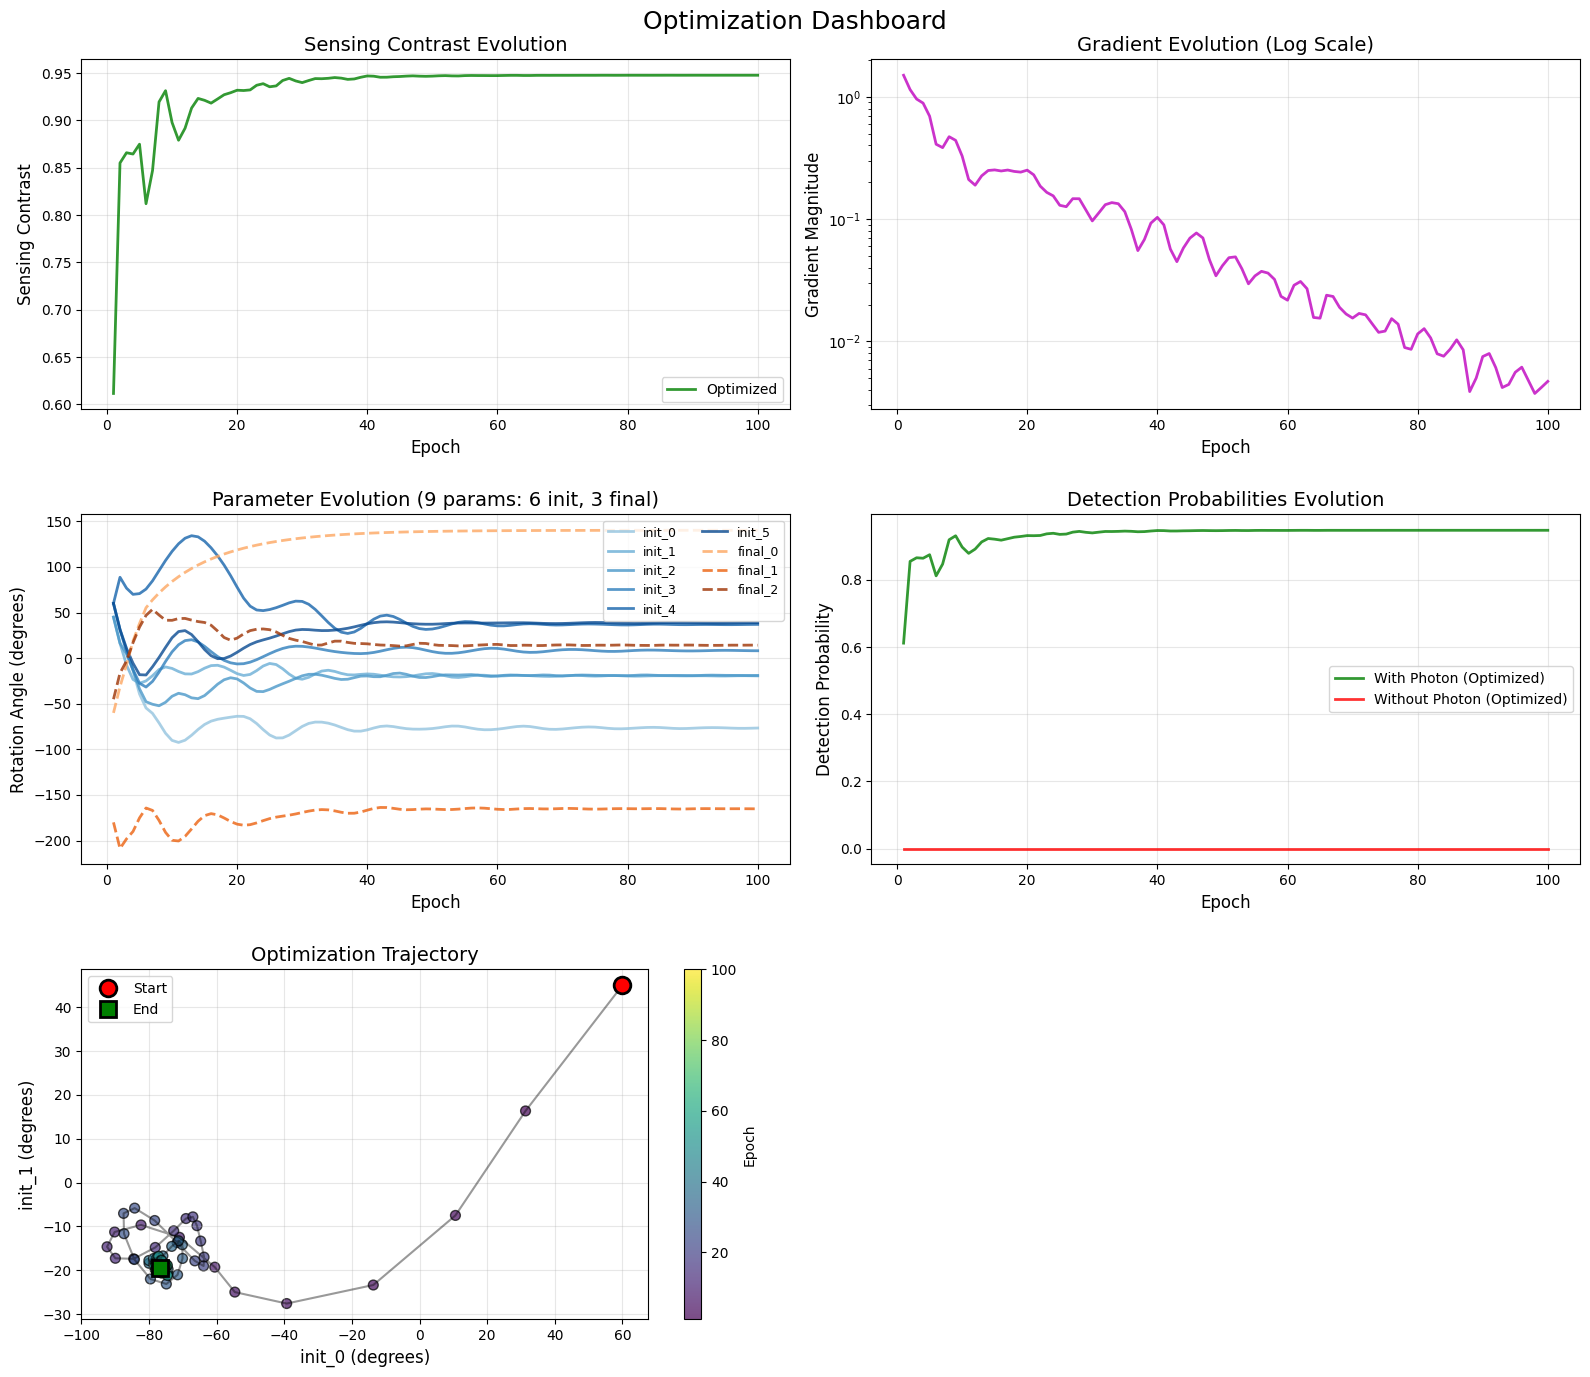

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt_00,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_detection_measures=True,
    figsize=(16, 14)
)
plt.show()


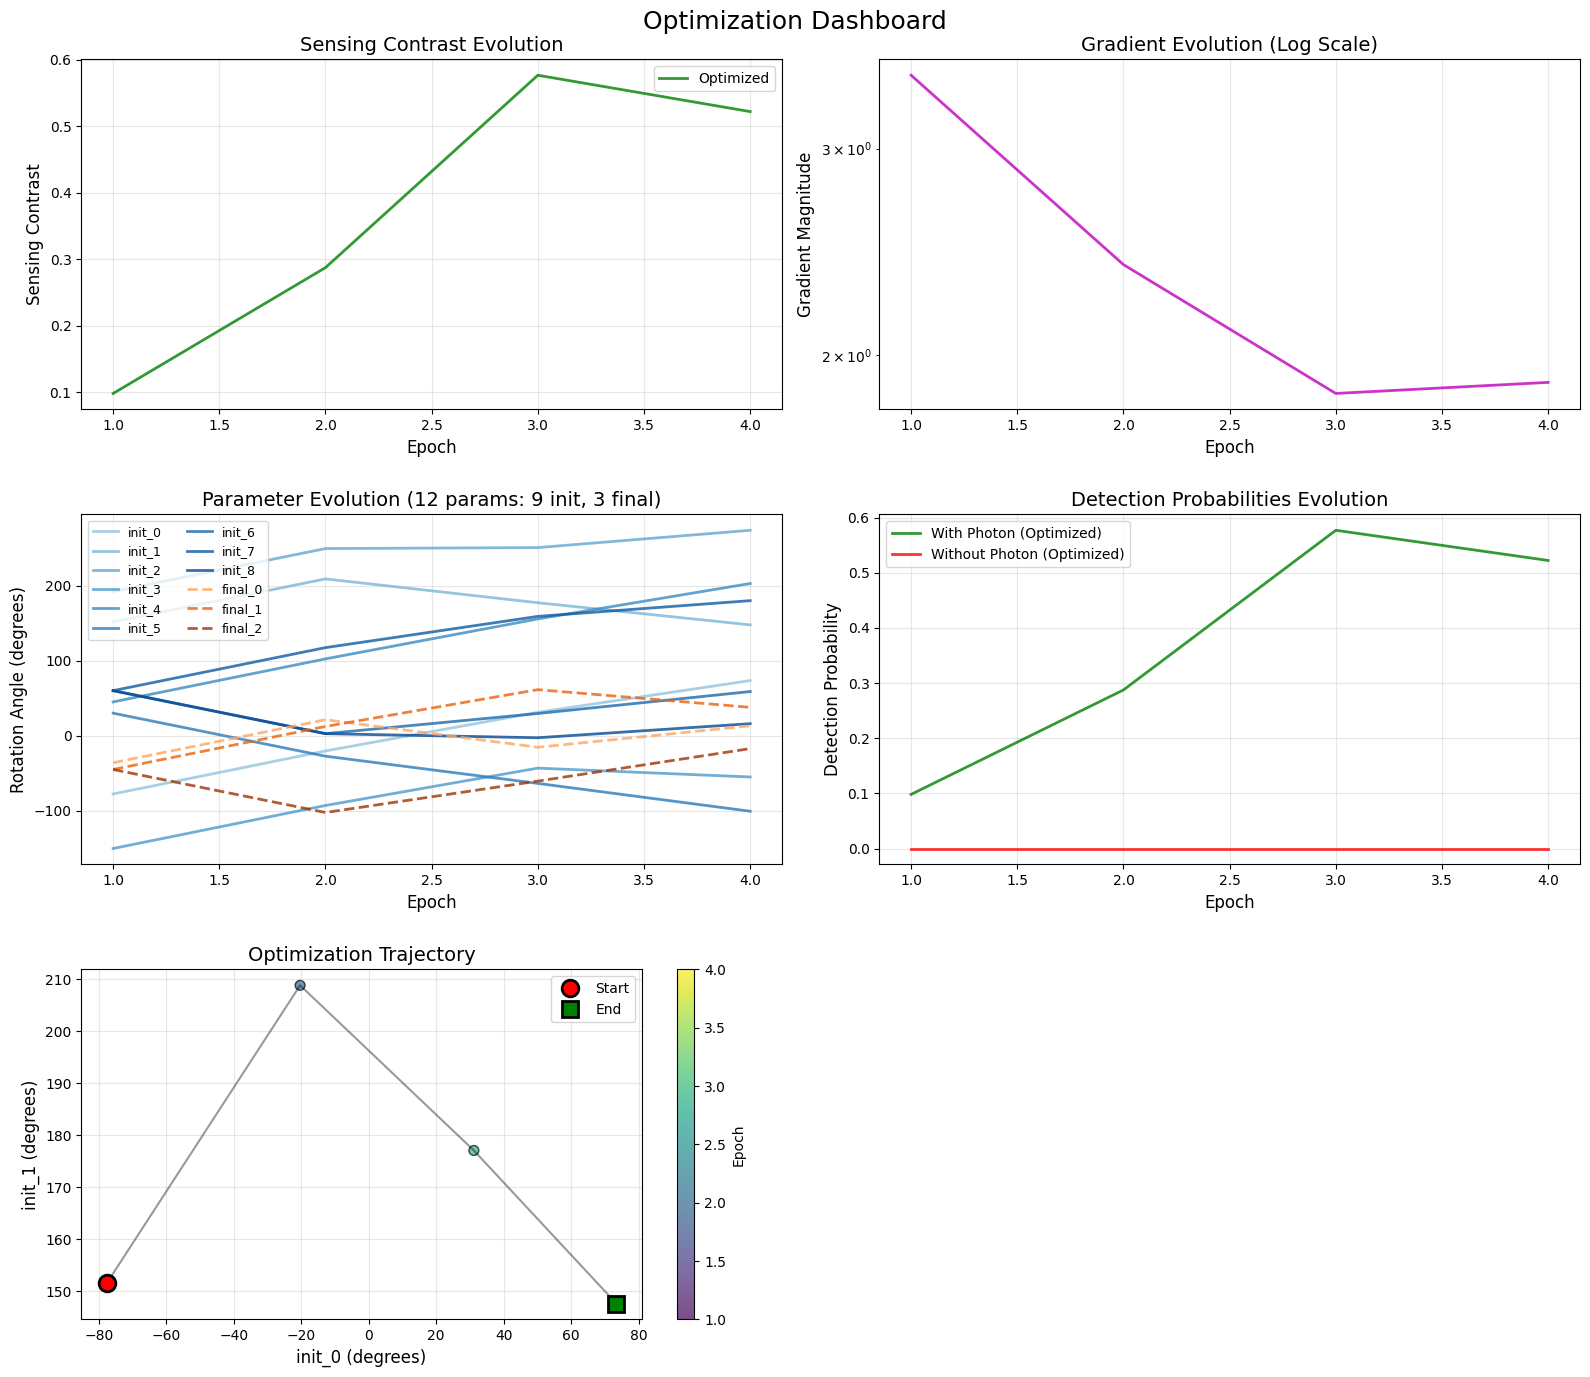

In [ ]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard showing all optimization metrics
fig = plot_optimization_dashboard(
    callback_opt_10,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_detection_measures=True,
    figsize=(16, 14)
)
plt.show()
